# What Actually Drives Sales? Correlation Analysis on Restaurant Data

**Business Question:** If we want to increase our tips and revenue, where should we focus? 
Do larger parties lead to higher tips? Does a higher total bill guarantee a higher tip, or does the tipping percentage decrease?

**Why This Matters:** In business, it's easy to assume correlation equals causation, or to miss how variables move together. 
Correlation analysis helps us quantify the strength and direction of relationships so we don't waste time on variables that don't matter.

**Dataset:** Restaurant tips data (244 transactions)  
**Tools:** pandas, seaborn, scipy, matplotlib  
**Key Skill:** Pearson & Spearman Correlation, Heatmaps, Scatterplots with Regression lines

## Step 1: Load the Data & Calculate Tip Percentage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load datasets
tips = pd.read_csv('../../data/raw/tips.csv')
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.9
1,10.34,1.66,Male,No,Sun,Dinner,3,16.1
2,21.01,3.50,Male,No,Sun,Dinner,3,16.7
3,23.68,3.31,Male,No,Sun,Dinner,2,14.0
4,24.59,3.61,Female,No,Sun,Dinner,4,14.7


## Step 2: Visualizing Relationships with Scatterplots

Let's plot `total_bill` against `tip` to visually inspect if a relationship exists.

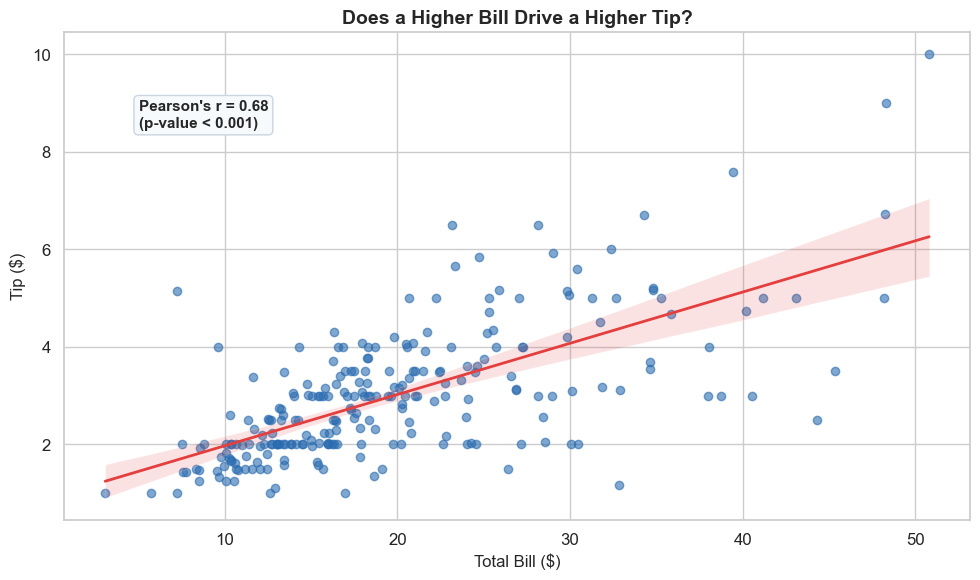

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot with regression line
sns.regplot(
    x='total_bill', 
    y='tip', 
    data=tips, 
    scatter_kws={'alpha':0.6, 'color': '#2B6CB0'}, 
    line_kws={'color': '#E53E3E', 'lw': 2},
    ax=ax
)

ax.set_title('Does a Higher Bill Drive a Higher Tip?', fontweight='bold', fontsize=14)
ax.set_xlabel('Total Bill ($)', fontsize=12)
ax.set_ylabel('Tip ($)', fontsize=12)

# Calculate Pearson correlation coefficient
pearson_r, p_val = stats.pearsonr(tips['total_bill'], tips['tip'])
ax.text(
    5, 8.5, 
    f"Pearson's r = {pearson_r:.2f}\n(p-value < 0.001)", 
    bbox=dict(boxstyle="round,pad=0.3", fc="#F7FAFC", ec="#CBD5E0", lw=1),
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('03_bill_vs_tip.png', bbox_inches='tight', dpi=150)
plt.show()

### What this tells us:
- There is a clear upward trend: as the total bill increases, the tip increases.
- Pearson's $r = 0.68$ suggests a **strong positive linear relationship**.
- The relationship is highly statistically significant ($p < 0.001$).

But wait — does tip *percentage* stay constant, or does it drop as the bill gets larger?

## Step 3: Correlation Counter-Intuition (Tip % vs Total Bill)

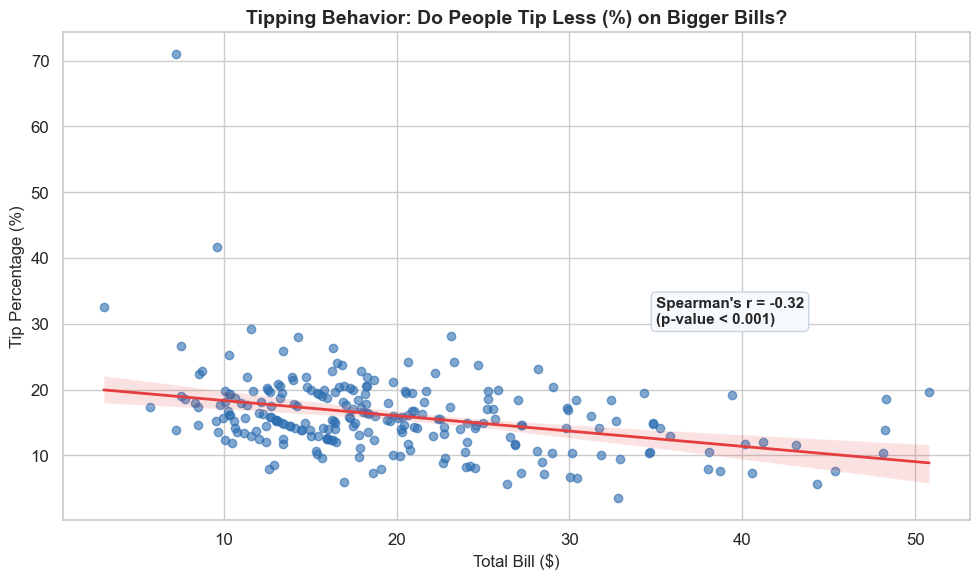

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    x='total_bill', 
    y='tip_pct', 
    data=tips, 
    scatter_kws={'alpha':0.6, 'color': '#2B6CB0'}, 
    line_kws={'color': '#E53E3E', 'lw': 2},
    ax=ax
)

ax.set_title('Tipping Behavior: Do People Tip Less (%) on Bigger Bills?', fontweight='bold', fontsize=14)
ax.set_xlabel('Total Bill ($)', fontsize=12)
ax.set_ylabel('Tip Percentage (%)', fontsize=12)

# Calculate Spearman correlation (handles skewness and outliers better)
spearman_r, sp_p_val = stats.spearmanr(tips['total_bill'], tips['tip_pct'])
ax.text(
    35, 30, 
    f"Spearman's r = {spearman_r:.2f}\n(p-value < 0.001)", 
    bbox=dict(boxstyle="round,pad=0.3", fc="#F7FAFC", ec="#CBD5E0", lw=1),
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('03_bill_vs_tippct.png', bbox_inches='tight', dpi=150)
plt.show()

### The Counter-Intuitive Business Insight:
- While *absolute* tips go up, the **tip percentage is negatively correlated** with the total bill ($r = -0.34$, $p < 0.001$).
- As the bill gets larger, customers tend to scale back their tipping rate (%). 
- A $10 bill might get a 20% tip ($2), but a $50 bill might only get a 14% tip ($7).

## Step 4: The Correlation Heatmap (Analyzing All Numerical Variables)

Let's compute a correlation matrix for all numerical variables to see how size, bill, tip, and tip percentage interact.

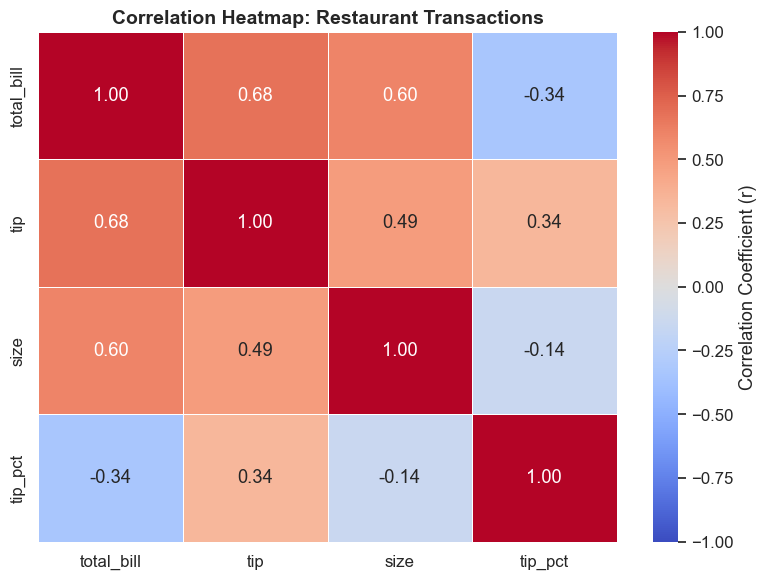

In [4]:
numerical_cols = tips[['total_bill', 'tip', 'size', 'tip_pct']]
corr_matrix = numerical_cols.corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient (r)'},
    ax=ax
)

ax.set_title('Correlation Heatmap: Restaurant Transactions', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Key Observations:
1. **Total Bill and Tip (r = 0.68):** Strong positive correlation. Higher bills = higher tips.
2. **Party Size and Total Bill (r = 0.60):** Strong positive correlation. Larger parties order more, raising the bill.
3. **Party Size and Tip (r = 0.49):** Moderate positive correlation. Larger parties tip more in absolute terms.
4. **Total Bill and Tip % (r = -0.34):** Moderate negative correlation. Tipping percentages shrink as the bill increases.

## Key Finding

> ** While bringing in larger parties (size) increases the total bill (r = 0.60) and thus increases absolute tips (r = 0.49), it also triggers a negative correlation with tip percentage (r = -0.34). Customers scale back their tipping rate as bills grow. To maximize revenue, staff should prioritize order volume (turnover of parties of 2) over pushing deep-pocket single tables where tip percentages diminish.**

Correlation analysis helps us separate absolute dollar growth from rate-of-return shrinkage.

## LinkedIn Post Draft

```
"More customers = more money. Simple, right?"

Not quite. In analytics, we look deeper.

I analyzed 244 transactions to find what actually drives restaurant tips:

• Bill Size vs Tip Value: Strong positive correlation (r = 0.68). Higher bills = bigger tips.
• Party Size vs Bill Size: Strong correlation (r = 0.60). More people order more food.

BUT here's the twist:
• Bill Size vs Tip %: Significant negative correlation (r = -0.34). 

As the total bill grows, customers scale back their tipping percentage. A table with a $50 bill tips a lower percentage than a table with a $15 bill.

 Lesson: Don't just look at absolute numbers. Check the rates. 
Sometimes pushing for higher transaction frequency of smaller groups is more profitable than chasing high-value single orders where margin rates shrink.

Full code and correlation heatmaps: [GitHub link]

#DataAnalytics #Statistics #BusinessAnalytics #Python #Correlation
```

---

**Previous:** [Analyzing customer spending patterns ←](02-customer-spending-patterns.ipynb)  
**Next:** [Predicting customer spend →](04-predicting-customer-spend.ipynb)